In [2]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader
from lib.dataloader import OCTSegDataset
import torch
import numpy as np
import cv2
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import os
from glob import glob
from matplotlib.colors import ListedColormap
# from lib.models.model_zoo.t_net import tnet
# from lib.models.model_zoo.ResNet50UNet import ResNet50UNet
from lib.models.UOCNet import UOCNet
from lib.models.UNET_OCT import UNET_OCT

# Function all in one place

# Segmentation Model

In [193]:
def convert_bn_to_gn(model, num_groups=32):
    for name, module in model.named_children():
        # If the module itself is BatchNorm, replace it
        if isinstance(module, nn.BatchNorm2d):
            num_channels = module.num_features
            gn = nn.GroupNorm(num_groups, num_channels)
            setattr(model, name, gn)

        # Otherwise, recurse
        else:
            convert_bn_to_gn(module, num_groups)

In [223]:
# from train import convert_bn_to_gn


class SegPredictor:
    def __init__(self, checkpoint_path, num_classes=4, crop_size=512, device=None, resize=False):
        # Choose device automatically if not specified
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.num_classes = num_classes
        self.crop_size = crop_size
        self.resize = resize

        # Define preprocessing pipeline
        self.transform = transforms.Compose([
            transforms.Resize((crop_size, crop_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.0918, 0.0918, 0.0918], std=[0.1903, 0.1903, 0.1903])
            # transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

        # Initialize model
        self.model = self._initialize_model()
        self.model.to(self.device)

        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(checkpoint["state_dict"])
        self.model.eval()
    # def convert_bn_to_gn(model, num_groups=32):
    #     for name, module in model.named_children():
    #         # If the module itself is BatchNorm, replace it
    #         if isinstance(module, nn.BatchNorm2d):
    #             num_channels = module.num_features
    #             gn = nn.GroupNorm(num_groups, num_channels)
    #             setattr(model, name, gn)

    #         # Otherwise, recurse
    #         else:
    #             convert_bn_to_gn(module, num_groups)
    def _initialize_model(self):
        """Initialize model."""
        # model = ResNet50UNet(num_classes=self.num_classes)
        model = models.segmentation.deeplabv3_resnet50(
            weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
        )
        model.classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
        convert_bn_to_gn(model, num_groups=32)
        return model

    def _undo_padding(self, pred_img, original_size=(1400, 850), target_size=(512, 512)):
        "Removes padding and resizes prediction back to the original image size."
        th, tw = target_size
        oh, ow = original_size

        scale = min(tw / ow, th / oh)
        new_w, new_h = int(ow * scale), int(oh * scale)

        pad_w = (tw - new_w) // 2
        pad_h = (th - new_h) // 2

        cropped = pred_img[pad_h:pad_h+new_h, pad_w:pad_w+new_w]
        img_resized = cv2.resize(cropped, (ow, oh), interpolation=cv2.INTER_NEAREST)

        return img_resized

    def _resize_with_padding(self, img, target_size=(1400, 850), is_mask=False):
        "Resize while preserving aspect ratio, then pad to target size. For mask, use nearest interpolation."
        h, w = img.shape[:2]
        th, tw = target_size

        scale = min(tw / w, th / h)
        new_w, new_h = int(w * scale), int(h * scale)

        interpolation = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
        resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

        pad_w = (tw - new_w) // 2
        pad_h = (th - new_h) // 2

        padded = cv2.copyMakeBorder(
            resized,
            pad_h, th - new_h - pad_h,
            pad_w, tw - new_w - pad_w,
            cv2.BORDER_CONSTANT,
            value=0
        )
        return padded

    def predict(self, image_path):
        """Run inference on a single image and return predicted mask."""
        # Load and preprocess image
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if self.resize:
            image = image[:1400, :850]
        # print('Original image shape:', image.shape)
        # image = self._resize_with_padding(image, is_mask=False)
        image = np.stack([image]*3, axis=-1)  # HxWx3

        img_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(self.device)
        img_tensor = img_tensor / 255.0
        img_tensor = (img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min())
        # print(img_tensor.shape)
        # image = Image.open(image_path).convert("RGB")
        # img_tensor = self.transform(image).unsqueeze(0).to(self.device)

        # Inference
        with torch.no_grad():
            out_dict = self.model(img_tensor)
            output = out_dict['out'] if isinstance(out_dict, dict) else out_dict
            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        # pred = self._undo_padding(pred)
        # image = self._undo_padding(np.array(image))
        return image, pred


In [4]:
import numpy as np
from skimage import morphology

def postprocess(pred, open_radius=35, close_radius=20):
    """
    pred: HxW multi-class mask with values {0,1,2,3}
    returns: processed mask with the same number of classes
    """

    # Structuring elements
    selem_open = morphology.disk(open_radius)
    selem_close = morphology.disk(close_radius)

    # Output mask
    processed = np.zeros_like(pred)

    # Number of classes
    num_classes = pred.max() + 1

    # Process each class separately (except background = 0)
    for c in range(1, num_classes):
        class_mask = (pred == c)  # extract mask of a single class

        # Apply morphology to this class
        m = morphology.opening(class_mask, selem_open)
        m = morphology.closing(m, selem_close)

        # Assign cleaned pixels back to processed output
        processed[m] = c

    return processed


In [18]:
from skimage.morphology import remove_small_objects, remove_small_holes
import numpy as np

def clean(pred, min_size=100, min_hole_size=50):
    """
    pred: HxW multi-class mask (0,1,2,3)
    Removes small unwanted pixel regions but keeps edges sharp.
    """

    cleaned = np.zeros_like(pred)
    num_classes = pred.max() + 1

    for c in range(1, num_classes):
        mask = (pred == c)

        # remove tiny isolated blobs
        mask = remove_small_objects(mask, min_size=min_size)

        # fill tiny holes inside large objects
        mask = remove_small_holes(mask, area_threshold=min_hole_size)

        cleaned[mask] = c

    return cleaned


Original image shape: (1400, 850)


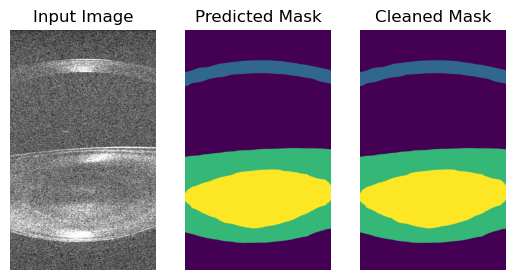

In [6]:
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth"
checkpoint_path = "runs/DeepLabV3_ResNet50_20251107_113953/checkpoints/DeepLabV3_ResNet50_epoch_20.pth"

predictor = SegPredictor(checkpoint_path, num_classes=4, crop_size=512, resize=True)

# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/dataset/images/CN039_AK_27_F_OD_6-0D_4_Vertical.png"
img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/Image.png"

image, pred = predictor.predict(img_path)
# pred = pred[:, 215:635]
pred3 = postprocess(pred, open_radius=20, close_radius=30)
pred3 = clean(pred, min_size=30000, min_hole_size=100)

# image2 = image[:, 215:635]
# pred2 = pred[:, 215:635]

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred)#, cmap='gray', vmin=0, vmax=3)
plt.title("Predicted Mask")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(pred3)#, cmap='gray', vmin=0, vmax=3)
plt.title("Cleaned Mask")
plt.axis("off")
plt.show()

In [ ]:
image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/dataset/images"
image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data/images/train"

image_files = glob(os.path.join(image_dir, "*.png"))
for i, img_path in enumerate(image_files, start=1):
    image_name = os.path.basename(img_path)
    image_name = os.path.splitext(image_name)[0]
    # print(f"Processing {image_name}...")
    image, pred = predictor.predict(img_path)
    # pred = pred[:, 215:635]
    # pred3 = postprocess(pred, open_radius=5, close_radius=1)
    # pred3 = clean(pred3, min_size=30000, min_hole_size=5)
    # image = image[:, 215:635]
    # pred = pred[:, 215:635]
    print(f'count number {i}: {image_name}')
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred)  # , cmap='gray', vmin=0, vmax=3)
    plt.title("Predicted Mask")
    plt.axis("off")
    # plt.subplot(1, 3, 3)
    # plt.imshow(pred3)#, cmap='gray', vmin=0, vmax=3)
    # plt.title("Cleaned Mask")
    # plt.axis("off")
    plt.show()

In [7]:
class OpticalAnalyzer:
    def __init__(self, x_pix=7.1/1000, y_pix=9.819/1000, n_values=None):
        self.x_pix = x_pix
        self.y_pix = y_pix
        self.n_values = n_values or [1, 1.3665, 1.3266, 1.3749, 1.3947, 1.3749]

    # ---- Helper Functions ----
    def polyfit(self, x, y, deg=3):
        mask = ~np.isnan(x) & ~np.isnan(y)
        if np.sum(mask) < deg + 1:
            return np.full_like(y, np.nan, dtype=float)
        fit_value = np.polyfit(x[mask], y[mask], deg)
        model = np.poly1d(fit_value)
        y_fit = np.full_like(y, np.nan, dtype=float)
        y_fit[mask] = model(x[mask])
        return y_fit

    def extract_surface(self, mask):
        H, W = mask.shape
        anterior, posterior = np.zeros(W), np.zeros(W)
        for col in range(W):
            ys = np.where(mask[:, col] > 0)[0]
            if len(ys) > 0:
                anterior[col] = ys[1] if len(ys) > 1 else ys[0]
                posterior[col] = ys[-2] if len(ys) > 3 else ys[-1]
            else:
                anterior[col] = posterior[col] = np.nan
        x = np.arange(W)
        return x, anterior, posterior

    def compute_optical_positions(self, I_layers):
        num_layers = len(I_layers)
        if len(self.n_values) != num_layers:
            raise ValueError("Refractive index list size mismatch")
        O = [I_layers[0].copy()]
        od, gd = [], [0.0]
        for i in range(num_layers - 1):
            od_i = I_layers[i + 1] - I_layers[i]
            gd_i = od_i / self.n_values[i+1]
            od.append(od_i)
            gd.append(gd_i)
            O.append(O[-1] + gd_i)
        return {"O": O, "od": od, "gd": gd}

    def fit_circle(self, x, y):
        mask = ~np.isnan(x) & ~np.isnan(y)
        x, y = x[mask], y[mask]
        A = np.c_[2*x, 2*y, np.ones(len(x))]
        b = x**2 + y**2
        c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        xc, yc = c[0], c[1]
        radius = np.sqrt(c[2] + xc**2 + yc**2)
        return xc, yc, radius

    # ---- Main Pipeline ----
    def raytracing(self, pred):
        # pred2 = pred[:, 215:635]
        pred2 = pred

        # masks
        cornea = (pred2 == 1).astype(np.uint8)
        lens = (pred2 == 2).astype(np.uint8)
        nucleus = (pred2 == 3).astype(np.uint8)

        # surfaces
        x1, y1, y2 = self.extract_surface(cornea)
        x2, y1_lens, y2_lens = self.extract_surface(lens)
        x3, y1_nuc, y2_nuc = self.extract_surface(nucleus)

        y1_fit = self.polyfit(x1, y1)
        y2_fit = self.polyfit(x1, y2)
        y1_lens_fit = self.polyfit(x2, y1_lens)
        y1_nuc_fit = self.polyfit(x3, y1_nuc)
        y2_nuc_fit = self.polyfit(x3, y2_nuc)
        y2_lens_fit = self.polyfit(x2, y2_lens)
        # use fitted curves
        y1, y2 = y1_fit, y2_fit
        y1_lens, y2_lens = y1_lens_fit, y2_lens_fit
        y1_nuc, y2_nuc = y1_nuc_fit, y2_nuc_fit

        # convert to physical space
        x1p, x2p, x3p = x1*self.x_pix, x2*self.x_pix, x3*self.x_pix
        y1p, y2p = y1*self.y_pix, y2*self.y_pix
        y1_lensp, y2_lensp = y1_lens*self.y_pix, y2_lens*self.y_pix
        y1_nucp, y2_nucp = y1_nuc*self.y_pix, y2_nuc*self.y_pix

        # polynomial fits
        I1 = self.polyfit(x1p, y1p)
        I2 = self.polyfit(x1p, y2p)
        I3 = self.polyfit(x2p, y1_lensp)
        I4 = self.polyfit(x3p, y1_nucp)
        I5 = self.polyfit(x3p, y2_nucp)
        I6 = self.polyfit(x2p, y2_lensp)

        # compute optical geometry
        results = self.compute_optical_positions([I1, I2, I3, I4, I5, I6])
        O_layers, gd_layers = results["O"], results["gd"]

        # circle fitting
        radii = []
        for x, O in zip([x1p, x1p, x1p, x1p, x1p, x1p], O_layers):
            _, _, r = self.fit_circle(x, O)
            radii.append(r)

        results2 = {"radii": radii,
                    "gd": gd_layers}
        
        curves = np.vstack([
            y1,           # Cornea anterior
            y2,           # Cornea posterior
            y1_lens,      # Lens anterior
            y1_nuc,   # Nucleus anterior
            y2_nuc,   # Nucleus posterior
            y2_lens       # Lens posterior
        ])
        curves_clean = np.nan_to_num(np.round(curves), nan=-1).astype(np.float64)
        return results2, curves_clean, O_layers


## Test Ref Segmentation Mask

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv2

H, W = 4096, 850
class bin_segmentation:
    def __init__(self, mask):
        self.mask = mask
    
    def get_mask(self, data_root):
        segmentation = np.fromfile(data_root + "Segmentation.bin", dtype = np.uint8)
        segmentation = segmentation[:H*W].reshape(W, H).T
        segmentation = segmentation[:1400, :850]
        binary_image = (segmentation == 255).astype(np.uint8)

        # plt.imshow(binary_image, cmap='gray')

        height, width = binary_image.shape
        # print('height, width:', height, width)
        mask = np.zeros((height, width), np.uint8)
        # print('unique values in mask:', np.unique(mask, return_counts = True))
        # ---- Layer pairs for segmentation ----
        layer_pairs = {
            1 :(2, 3),  # Cornea
            2 :(4, 7),  # Lens
            3 :(5, 6)   # Nucleus
        }

        all_layers = [np.sort(np.where(binary_image[:, x] ==1)[0]) for x in range(width)]

        def compute_x_range(layer_index):
            first_200 = [(x, all_layers[x][layer_index]) for x in range(min(200, width)) if len(all_layers[x]) > layer_index]
            last_200 = [(x, all_layers[x][layer_index]) for x in range(max(width-200, 0), width) if len(all_layers[x]) > layer_index]

            x_start = max(first_200, key=lambda item: item[1])[0] if first_200 else 0
            x_end = max(last_200, key=lambda item: item[1])[0] if last_200 else 0

            return x_start, x_end


        x5_start, x5_end = compute_x_range(4) # 5th layer (nucleus top)
        # x6_start, x6_end = compute_y6_range(5) # 6th layer (nucleus bottom)

        for x in range(width):
            ys = all_layers[x]
            if len(ys) == 0:
                continue
            
            for layer_num, (y_start, y_end) in layer_pairs.items():
                if y_start <= len(ys) and y_end <= len(ys):
                    y_top, y_bottom = ys[y_start - 1], ys[y_end - 1]

                    if layer_num == 3:  # Nucleus
                        if x5_start is None or x5_end is None or not (x5_start + 1 <= x <= x5_end-1):
                            continue
                    # if layer_num == 3:  # Nucleus
                    #     if x6_start is None or x6_end is None or not (x6_start + 1 <= x < x6_end):
                    #         continue

                    label = cv2.line(mask, (x, y_top), (x, y_bottom), color=layer_num, thickness=1)
                    
                    
        label = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
        return label

In [9]:
data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/0-6/4/Horizontal/"
data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/0-6/4/Vertical/"
data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/6-0/4/Horizontal/"
data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/6-0/4/Vertical/"

bin_seg = bin_segmentation(mask=None)
label = bin_seg.get_mask(data_root=data_root)

analyzer = OpticalAnalyzer()
results, curves, O = analyzer.raytracing(label)

gd_layers =results['gd']
roc = results["radii"]
gd_mean = [np.nanmean(gd) for gd in results["gd"]]
d1 = np.sum(gd_mean[:3])
d2 = np.sum(gd_mean[3:])

data2 = {
    "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                + ["D1", "D2"]+
            ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
    # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
    "Value (mm)": [*gd_mean, d1, d2, *roc]
}
df2 = pd.DataFrame(data2)
df2

# for val in df2["Value (mm)"]:
#     print(f"{val:.4f}")


,Layer,Value (mm)
0,GD Cornea Anterior,0.000000
1,GD Cornea Posterior,0.596423
2,GD Lense Anterior,3.200516
3,GD Nucleus Anterior,1.077445
4,GD Nucleus Posterior,1.637815
5,GD Lens Posterior,0.728274
6,D1,3.796939
7,D2,3.443534
8,RoC Cornea Anterior,7.637555
9,RoC Cornea Posterior,7.079677


### Single Image Prediction and Raytracing

Original image shape: (1400, 850)


,Layer,Value (mm)
0,GD Cornea Anterior,0.000000
1,GD Cornea Posterior,0.524906
2,GD Lense Anterior,3.177554
3,GD Nucleus Anterior,1.048296
4,GD Nucleus Posterior,1.709863
5,GD Lens Posterior,0.843996
6,D1,3.702460
7,D2,3.602155
8,RoC Cornea Anterior,7.428793
9,RoC Cornea Posterior,7.080595


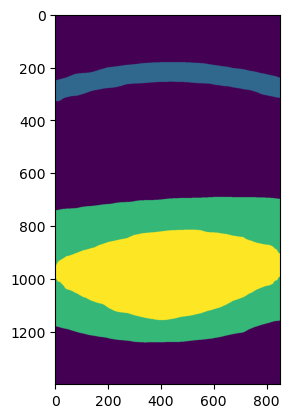

In [10]:
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth"
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth" # Mix data
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251105_165715/checkpoints/DeepLabV3_ResNet50_best.pth"  # Mix2 data
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251106_091849/checkpoints/DeepLabV3_ResNet50_best.pth" # Mix2 data without augmentation+ combined loss
# checkpoint_path = "runs/ResNet50UNet_DAC_20251106_114438/checkpoints/ResNet50UNet_DAC_best.pth" # without padding, orginal size 1400x850 not working well
checkpoint_path = "runs/DeepLabV3_ResNet50_20251107_113953/checkpoints/DeepLabV3_ResNet50_epoch_20.pth"

# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/dataset/eye_data/images/val/CN035_JP_19_M_OD_6-0D_4_Horizontal.png"
# img_path ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/Image.png"

data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Vertical/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/6-0/0/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/6-0/0/Vertical/"

img_path = data_root + "Image.png"

predictor = SegPredictor(checkpoint_path, num_classes=4, crop_size=512, resize=True)
image, pred = predictor.predict(img_path)
image2 = image[:, 215:635]
# pred = pred[:, 215:635]
# pred2 = postprocess(pred, open_radius=20, close_radius=30)
# pred = clean(pred2, min_size=30000, min_hole_size=100)

plt.imshow(pred)
analyzer = OpticalAnalyzer()
results, curves, O = analyzer.raytracing(pred)

gd_layers =results['gd']
roc = results["radii"]
gd_mean = [np.nanmean(gd) for gd in results["gd"]]
d1 = np.sum(gd_mean[:3])
d2 = np.sum(gd_mean[3:])

data = {
    "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                + ["D1", "D2"]+
            ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
    # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
    "Value (mm)": [*gd_mean, d1, d2, *roc]
}
df = pd.DataFrame(data)
df
# csv_path = "optical_results.csv"
# excel_path = "optical_results.xlsx"
# df.to_csv(csv_path, index=False)
# df.to_excel(excel_path, index=False, engine="openpyxl")

# for idx, val in enumerate(gd_mean, start=1):
#     print(f"GD{idx}: {val:.4f} mm")
# print(f"d1: {d1:.3f} mm\nd2: {d2:.3f} mm")

# for idx, r in enumerate(results["radii"], start=1):
#     print(f"RoC {idx}: {r:.3f} mm")


In [ ]:
np.savetxt("label_CN035_6-0D_4_H.csv", curves, fmt="%d", delimiter=",")

In [26]:
df

,Layer,Value (mm)
0,GD Cornea Anterior,0.000000
1,GD Cornea Posterior,0.556877
2,GD Lense Anterior,3.227550
3,GD Nucleus Anterior,0.915605
4,GD Nucleus Posterior,2.151962
5,GD Lens Posterior,0.729039
6,D1,3.784428
7,D2,3.796607
8,RoC Cornea Anterior,5.305840
9,RoC Cornea Posterior,6.097954


In [ ]:
checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth"
predictor = SegPredictor(checkpoint_path, num_classes=4, crop_size=512)

image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/dataset/training/images/val"
results_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/results"
os.makedirs(results_dir, exist_ok=True)
# csv_path = os.path.join(results_dir, "optical_results.csv")
# excel_path = os.path.join(results_dir, "optical_results.xlsx")
# curves_dir = os.path.join(results_dir, "curves.csv")


image_files = glob(os.path.join(image_dir, "*.png"))
for img_path in image_files:
    image_name = os.path.basename(img_path)
    image_name = os.path.splitext(image_name)[0]
    # print(f"Processing {image_name}...")
    
    image, pred = predictor.predict(img_path)
    image = image[:, 215:635]
    pred = pred[:, 215:635]
    # pred = postprocess(pred, open_radius=20, close_radius=30)
    pred = clean(pred, min_size=30000, min_hole_size=100)   # to remove small patches

    analyzer = OpticalAnalyzer()
    results, curves, O = analyzer.raytracing(pred)

    gd_layers =results['gd']
    roc = results["radii"]
    gd_mean = [np.nanmean(gd) for gd in results["gd"]]
    d1 = np.sum(gd_mean[:3])
    d2 = np.sum(gd_mean[3:])

    data = {
        "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                    + ["D1", "D2"]+
                ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
        # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
        "Value (mm)": [*gd_mean, d1, d2, *roc]
    }
    df = pd.DataFrame(data)
    # df
    final_dir = os.path.join(results_dir, image_name)
    os.makedirs(final_dir, exist_ok=True)
    csv_path = os.path.join(final_dir, "optical_results.csv")
    excel_path = os.path.join(final_dir, "optical_results.xlsx")
    curves_dir = os.path.join(final_dir, "curves.csv")

    df.to_csv(csv_path, index=False)
    df.to_excel(excel_path, index=False, engine="openpyxl")
    np.savetxt(curves_dir, curves, fmt="%d", delimiter=",")

print(f" {len(image_files)} images processed. Results saved in {results_dir}")

 166 images processed. Results saved in /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/results


: 

### Improvements

In [3]:
# from train import convert_bn_to_gn


class SegPredictor2:
    def __init__(self, checkpoint_path, num_classes=4, crop_size=512, device=None, resize=False, undo_padding=False, GN=False):
        # Choose device automatically if not specified
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.num_classes = num_classes
        self.crop_size = crop_size
        self.resize = resize
        self.undo_padding = undo_padding
        self.GN = GN

        # Define preprocessing pipeline
        self.transform = transforms.Compose([
            # transforms.Resize((crop_size, crop_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.0918, 0.0918, 0.0918], std=[0.1903, 0.1903, 0.1903]) # train config
            # transforms.Normalize(mean=[0.08,0.08,0.08], std=[0.5,0.5,0.5])
            # transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

        # Initialize model
        self.model = self._initialize_model()
        self.model.to(self.device)

        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        # self.model.load_state_dict(checkpoint["state_dict"])
        state_dict = checkpoint["state_dict"]
        new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        self.model.load_state_dict(new_state_dict)
        
        self.model.eval()
    # def convert_bn_to_gn(model, num_groups=32):
    #     for name, module in model.named_children():
    #         # If the module itself is BatchNorm, replace it
    #         if isinstance(module, nn.BatchNorm2d):
    #             num_channels = module.num_features
    #             gn = nn.GroupNorm(num_groups, num_channels)
    #             setattr(model, name, gn)

    #         # Otherwise, recurse
    #         else:
    #             convert_bn_to_gn(module, num_groups)
    def _initialize_model(self):
        """Initialize model."""
        # model = ResNet50UNet(num_classes=self.num_classes)
        model = models.segmentation.deeplabv3_resnet50(
            weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
        )
        model.classifier[4] = nn.Conv2d(256, self.num_classes, kernel_size=1)
        if self.GN:
            convert_bn_to_gn(model, num_groups=32)
        if torch.cuda.device_count() > 1:
            model = torch.nn.DataParallel(model)

        return model

    def _undo_padding(self, pred_img, original_size=(1400, 850), target_size=(512, 512)):
        "Removes padding and resizes prediction back to the original image size."
        th, tw = target_size
        oh, ow = original_size

        scale = min(tw / ow, th / oh)
        new_w, new_h = int(ow * scale), int(oh * scale)

        pad_w = (tw - new_w) // 2
        pad_h = (th - new_h) // 2

        cropped = pred_img[pad_h:pad_h+new_h, pad_w:pad_w+new_w]
        img_resized = cv2.resize(cropped, (ow, oh), interpolation=cv2.INTER_NEAREST)

        return img_resized

    def _resize_with_padding(self, img, target_size=(1400, 850), is_mask=False):
        "Resize while preserving aspect ratio, then pad to target size. For mask, use nearest interpolation."
        h, w = img.shape[:2]
        th, tw = target_size

        scale = min(tw / w, th / h)
        new_w, new_h = int(w * scale), int(h * scale)

        interpolation = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
        resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

        pad_w = (tw - new_w) // 2
        pad_h = (th - new_h) // 2

        padded = cv2.copyMakeBorder(
            resized,
            pad_h, th - new_h - pad_h,
            pad_w, tw - new_w - pad_w,
            cv2.BORDER_CONSTANT,
            value=0
        )
        return padded

    def predict(self, image_path):
        """Run inference on a single image and return predicted mask."""
        # Load and preprocess image
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if self.resize:
            image = image[:1400, :850]
        # print('Original image shape:', image.shape)
        # image = self._resize_with_padding(image, is_mask=False)
        image = np.stack([image]*3, axis=-1)  # HxWx3

        # img_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(self.device)
        # img_tensor = img_tensor / 255.0
        # img_tensor = (img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min())
        # print(img_tensor.shape)
        # image = Image.open(image_path).convert("RGB")
        img_tensor = self.transform(image).unsqueeze(0).to(self.device)
        # print('Image tensor shape:', img_tensor.shape)
        # Inference
        with torch.no_grad():
            out_dict = self.model(img_tensor)
            output = out_dict['out'] if isinstance(out_dict, dict) else out_dict
            pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
            # Get softmax probabilities
            # pred = torch.softmax(output, dim=1)[0].cpu().numpy()   # (C,H,W)
            # print('Pred shape (C,H,W):', pred.shape)
            
        if self.undo_padding:
            pred = self._undo_padding(pred)
            image = self._undo_padding(np.array(image))
        return image, pred


In [4]:
def undo_padding(pred_img, original_size=(1400, 850), target_size=(512, 512)):
        "Removes padding and resizes prediction back to the original image size."
        th, tw = target_size
        oh, ow = original_size

        scale = min(tw / ow, th / oh)
        new_w, new_h = int(ow * scale), int(oh * scale)

        pad_w = (tw - new_w) // 2
        pad_h = (th - new_h) // 2

        cropped = pred_img[pad_h:pad_h+new_h, pad_w:pad_w+new_w]
        img_resized = cv2.resize(cropped, (ow, oh), interpolation=cv2.INTER_NEAREST)

        return img_resized

Using checkpoint: runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth
Original image shape: (512, 512)
Image tensor shape: torch.Size([1, 3, 512, 512])
Pred shape (C,H,W): (512, 512)
Pred shape- (C,H,W): (1400, 850)


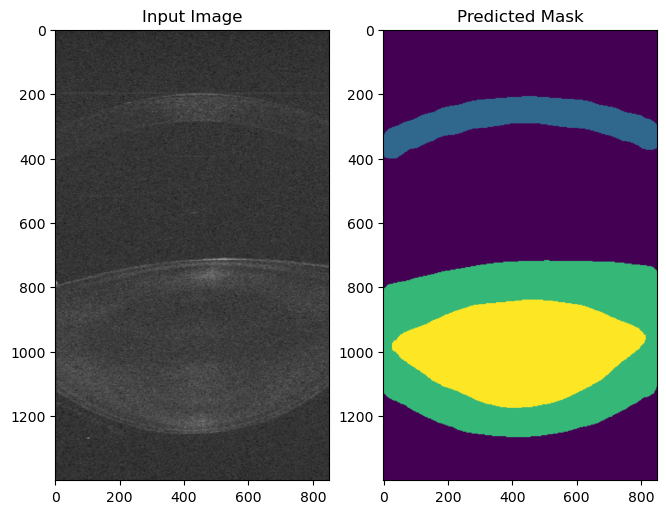

In [13]:
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth"
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251107_113953/checkpoints/DeepLabV3_ResNet50_epoch_20.pth"

# checkpoint_path = "test/DeepLabV3_ResNet50_epoch_10.pth" #nn.CrossEntropyLoss
# checkpoint_path = "test/DeepLabV3_ResNet50_best.pth"
checkpoint_path = "runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" # 512x512 padding (old data)
# checkpoint_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_310/DeepLabV3_ResNet50_epoch_10.pth"
print('Using checkpoint:', checkpoint_path)
predictor = SegPredictor2(checkpoint_path, num_classes=4, crop_size=512, resize=False, undo_padding=True)

# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/dataset/images/CN039_AK_27_F_OD_6-0D_4_Vertical.png"
# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/Image.png"

# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN068_IB_29_F\OS\0-6\0\Horizontal\Image.png"
img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train/pCN029_FK_24_M_OS_6-0D_0_Horizontal.png"
# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_310/images/train/pCN029_FK_24_M_OS_6-0D_0_Horizontal.png"

image, pred = predictor.predict(img_path)
# pred = pred[:, 215:635]
# pred3 = postprocess(pred, open_radius=20, close_radius=30)
# pred3 = clean(pred, min_size=30000, min_hole_size=100)

print('Pred shape- (C,H,W):', pred.shape)

# pred_classes = np.argmax(pred, axis=0)  # Convert probabilities to class labels
# image2 = image[:, 215:635]
# pred2 = pred[:, 215:635]

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
# plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred)#, cmap='gray', vmin=0, vmax=3)
plt.title("Predicted Mask")
# plt.axis("off")
# plt.subplot(1, 3, 3)
# # plt.imshow(pred3)#, cmap='gray', vmin=0, vmax=3)
# plt.title("Cleaned Mask")
# plt.axis("off")
plt.show()

#### RayTracing improvements

In [5]:
from scipy.signal import savgol_filter

def smooth_curve(y, window=31, poly=3):
    y2 = y.copy()
    mask = ~np.isnan(y)
    y2[mask] = savgol_filter(y[mask], window_length=window, polyorder=poly)
    return y2


def extract_surface(mask):
    H, W = mask.shape
    anterior = np.full(W, np.nan)
    posterior = np.full(W, np.nan)

    # compute boundaries using gradient
    edges = np.diff(mask.astype(np.int8), axis=0)  # vertical edges

    for col in range(W):
        col_edges = edges[:, col]

        # anterior = first rising edge (0 → 1)
        rising = np.where(col_edges == 1)[0]
        if len(rising) > 0:
            anterior[col] = rising[0] + 1  # +1 because diff reduces index

        # posterior = last falling edge (1 → 0)
        falling = np.where(col_edges == -1)[0]
        if len(falling) > 0:
            posterior[col] = falling[-1]  # boundary before falling
        
    return np.arange(W), anterior, posterior


In [6]:
import scipy.ndimage as ndi

def smooth_mask(mask):
    # 1. distance transform
    dist = ndi.distance_transform_edt(mask)
    # 2. smooth distance field
    dist_smooth = ndi.gaussian_filter(dist, sigma=1.5)
    # 3. reconstruct mask
    return (dist_smooth > 0.5).astype(np.uint8)


class OpticalAnalyzer2:
    def __init__(self, x_pix=7.1/1000, y_pix=9.819/1000, n_values=None):
        self.x_pix = x_pix
        self.y_pix = y_pix
        self.n_values = n_values or [1, 1.3665, 1.3266, 1.3749, 1.3947, 1.3749]

    # ---- Helper Functions ----
    def polyfit(self, x, y, deg=3):
        mask = ~np.isnan(x) & ~np.isnan(y)
        if np.sum(mask) < deg + 1:
            return np.full_like(y, np.nan, dtype=float)
        fit_value = np.polyfit(x[mask], y[mask], deg)
        model = np.poly1d(fit_value)
        y_fit = np.full_like(y, np.nan, dtype=float)
        y_fit[mask] = model(x[mask])
        return y_fit

    def extract_surface(self, mask):
        H, W = mask.shape
        anterior, posterior = np.zeros(W), np.zeros(W)
        for col in range(W):
            ys = np.where(mask[:, col] > 0)[0]
            if len(ys) > 0:
                anterior[col] = ys[1] if len(ys) > 1 else ys[0]
                posterior[col] = ys[-2] if len(ys) > 3 else ys[-1]
            else:
                anterior[col] = posterior[col] = np.nan
        x = np.arange(W)
        return x, anterior, posterior

    def compute_optical_positions(self, I_layers):
        num_layers = len(I_layers)
        if len(self.n_values) != num_layers:
            raise ValueError("Refractive index list size mismatch")
        O = [I_layers[0].copy()]
        od, gd = [], [0.0]
        for i in range(num_layers - 1):
            od_i = I_layers[i + 1] - I_layers[i]
            gd_i = od_i / self.n_values[i+1]
            od.append(od_i)
            gd.append(gd_i)
            O.append(O[-1] + gd_i)
        return {"O": O, "od": od, "gd": gd}

    def fit_circle(self, x, y):
        mask = ~np.isnan(x) & ~np.isnan(y)
        x, y = x[mask], y[mask]
        A = np.c_[2*x, 2*y, np.ones(len(x))]
        b = x**2 + y**2
        c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        xc, yc = c[0], c[1]
        radius = np.sqrt(c[2] + xc**2 + yc**2)
        return xc, yc, radius

    # ---- Main Pipeline ----
    def raytracing(self, pred):
        # pred2 = pred[:, 215:635]
        pred2 = pred
        # plt.imshow(pred2)
        # masks
        cornea = (pred2 == 1).astype(np.uint8)
        lens = (pred2 == 2).astype(np.uint8)
        nucleus = (pred2 == 3).astype(np.uint8)

        # cornea = smooth_mask(cornea)
        # lens = smooth_mask(lens)
        # nucleus = smooth_mask(nucleus)

        # surfaces
        # x1, y1, y2 = self.extract_surface(cornea)
        # x2, y1_lens, y2_lens = self.extract_surface(lens)
        # x3, y1_nuc, y2_nuc = self.extract_surface(nucleus)

        x1, y1, y2 = extract_surface(cornea)
        x2, y1_lens, y2_lens = extract_surface(lens)
        x3, y1_nuc, y2_nuc = extract_surface(nucleus)

        y1 = smooth_curve(y1)
        y2 = smooth_curve(y2)
        y1_lens = smooth_curve(y1_lens)
        y2_lens = smooth_curve(y2_lens)
        y1_nuc = smooth_curve(y1_nuc)
        y2_nuc = smooth_curve(y2_nuc)

        y1_fit = self.polyfit(x1, y1)
        y2_fit = self.polyfit(x1, y2)
        y1_lens_fit = self.polyfit(x2, y1_lens)
        y1_nuc_fit = self.polyfit(x3, y1_nuc)
        y2_nuc_fit = self.polyfit(x3, y2_nuc)
        y2_lens_fit = self.polyfit(x2, y2_lens)
        # use fitted curves
        y1, y2 = y1_fit, y2_fit
        y1_lens, y2_lens = y1_lens_fit, y2_lens_fit
        y1_nuc, y2_nuc = y1_nuc_fit, y2_nuc_fit

        # convert to physical space
        x1p, x2p, x3p = x1*self.x_pix, x2*self.x_pix, x3*self.x_pix
        y1p, y2p = y1*self.y_pix, y2*self.y_pix
        y1_lensp, y2_lensp = y1_lens*self.y_pix, y2_lens*self.y_pix
        y1_nucp, y2_nucp = y1_nuc*self.y_pix, y2_nuc*self.y_pix

        # polynomial fits
        I1 = self.polyfit(x1p, y1p)
        I2 = self.polyfit(x1p, y2p)
        I3 = self.polyfit(x2p, y1_lensp)
        I4 = self.polyfit(x3p, y1_nucp)
        I5 = self.polyfit(x3p, y2_nucp)
        I6 = self.polyfit(x2p, y2_lensp)

        # compute optical geometry
        results = self.compute_optical_positions([I1, I2, I3, I4, I5, I6])
        O_layers, gd_layers = results["O"], results["gd"]

        # circle fitting
        radii = []
        for x, O in zip([x1p, x1p, x1p, x1p, x1p, x1p], O_layers):
            _, _, r = self.fit_circle(x, O)
            radii.append(r)

        results2 = {"radii": radii,
                    "gd": gd_layers}
        
        curves = np.vstack([
            y1,           # Cornea anterior
            y2,           # Cornea posterior
            y1_lens,      # Lens anterior
            y1_nuc,   # Nucleus anterior
            y2_nuc,   # Nucleus posterior
            y2_lens       # Lens posterior
        ])
        # print('Curves shape:', curves.shape)
        curves_clean = np.nan_to_num(np.round(curves), nan=-1).astype(np.float64)
        # print('Curves clean shape:', curves_clean.shape)
        # print(len(curves_clean))
        return results2, curves_clean, O_layers


In [16]:
import cv2
import numpy as np

def smooth_maps(prob, ksize=5, sigma=1.0):
    smoothed = np.zeros_like(prob)
    for c in range(prob.shape[0]):
        smoothed[c] = cv2.GaussianBlur(prob[c], (ksize, ksize), sigma)
    return smoothed


In [7]:
import numpy as np
from skimage import morphology

def postprocess2(pred: np.ndarray, close_radius: int = 35, open_radius: int = 12) -> np.ndarray:
    """
    State-of-the-art morphological post-processing for retinal OCT layer segmentation.
    
    Args:
        pred: (H, W) integer mask with values 0=background, 1,2,3,...=layers
        close_radius: large = very smooth boundaries (30–40 typical)
        open_radius: small = removes salt-and-pepper noise (8–15 typical)
    
    Returns:
        Cleaned mask with no overlaps and beautiful smooth layers
    """
    if pred.ndim != 2:
        raise ValueError("pred must be 2D array")
    
    selem_close = morphology.disk(close_radius)
    selem_open  = morphology.disk(open_radius)
    
    processed = np.zeros_like(pred)
    num_classes = int(pred.max()) + 1
    
    # Process from background (0) to foreground classes
    # Higher classes can override lower ones if needed (optional)
    for c in range(1, num_classes):
        binary = (pred == c)
        
        # Crucial order: close first (smooth + fill holes), then open (remove tiny noise)
        cleaned = morphology.closing(binary, selem_close)
        cleaned = morphology.opening(cleaned, selem_open)
        
        # Critical: avoid overwriting already assigned pixels
        processed[cleaned & (processed == 0)] = c
    
    return processed

Label shape: (1400, 850)
Original image shape: (512, 512)
Image tensor shape: torch.Size([1, 3, 512, 512])
Pred shape (C,H,W): (512, 512)
Curves shape: (6, 850)
Curves clean shape: (6, 850)
6
Curves shape: (6, 850)
Curves clean shape: (6, 850)
6


,Layer,Prediction (mm),Reference (mm),MAE,MPE (%)
0,GD Cornea Anterior,0.000000,0.000000,0.000000,NaN
1,GD Cornea Posterior,0.618309,0.582172,0.036137,6.207359
2,GD Lense Anterior,3.198766,3.234898,0.036132,1.116959
3,GD Nucleus Anterior,1.074487,1.035636,0.038851,3.751405
4,GD Nucleus Posterior,1.587140,1.583389,0.003751,0.236916
5,GD Lens Posterior,0.863006,0.840001,0.023005,2.738723
6,D1,3.817075,3.817070,0.000005,0.000131
7,D2,3.524633,3.459026,0.065607,1.896705
8,RoC Cornea Anterior,4.864064,4.770862,0.093202,1.953564
9,RoC Cornea Posterior,4.450881,4.392185,0.058696,1.336380


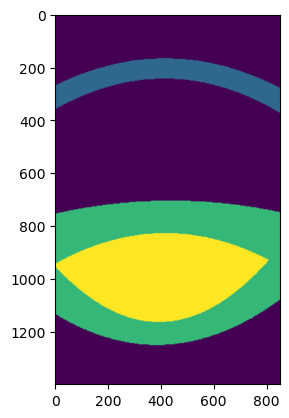

In [141]:

# checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth" # Mix data
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251105_165715/checkpoints/DeepLabV3_ResNet50_best.pth"  # Mix2 data
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251106_091849/checkpoints/DeepLabV3_ResNet50_best.pth" # Mix2 data without augmentation+ combined loss
# checkpoint_path = "runs/ResNet50UNet_DAC_20251106_114438/checkpoints/ResNet50UNet_DAC_best.pth" # without padding, orginal size 1400x850 not working well
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251107_113953/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" #best so far
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251110_121848/checkpoints/DeepLabV3_ResNet50_best.pth"

checkpoint_path = "runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" # 512x512 padding (old data)
# checkpoint_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_310/DeepLabV3_ResNet50_epoch_10.pth"

img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"
label_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/labels/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"

# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/dataset/eye_data/images/val/CN035_JP_19_M_OD_6-0D_4_Horizontal.png"
# img_path ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/Image.png"

# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Vertical/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/6-0/0/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/6-0/0/Vertical/"

# checkpoint_path = "test/DeepLabV3_ResNet50_best_cb.pth" #nn.CrossEntropyLoss
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\0-6\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\0-6\4\Vertical\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\6-0\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\6-0\4\Vertical\Image.png"

# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\0-6\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\0-6\4\Vertical\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\6-0\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\6-0\4\Vertical\Image.png"

# img_path = data_root + "Image.png"

label = Image.open(label_path).convert("L")  
label = undo_padding(np.array(label), original_size=(1400, 850), target_size=(512, 512))
plt.imshow(label)
print('Label shape:', np.array(label).shape)
predictor = SegPredictor2(checkpoint_path, num_classes=4, crop_size=512, resize=False, undo_padding=True)
image, pred = predictor.predict(img_path)

# pred = postprocess(pred, open_radius=12, close_radius=30)
# pred = clean(pred, min_size=30000, min_hole_size=100)
# pred = postprocess(pred, open_radius=10, close_radius=20)  # clean small noise
# pred = postprocess(pred, open_radius=20, close_radius=40)  # final smoothing

# Two-pass for perfect results
# pred = postprocess2(pred, close_radius=20, open_radius=10)  # light clean
# pred = postprocess2(pred, close_radius=40, open_radius=15)  # heavy smoothing

# image2 = image[:, 150:700]
# pred = pred[:, 150:700]
# label = label[:, 150:700]

# label = label[:, 215:635]
# pred = pred[:, 215:635]
# pred = smooth_maps(pred, ksize=1, sigma=4.0)
# pred = np.argmax(pred, axis=0).astype(np.uint8)  # Convert probabilities to class labels

# plt.imshow(pred[:, 215:635])

analyzer = OpticalAnalyzer2()
# results, curves, O = analyzer.raytracing(label)
results, curves, O = analyzer.raytracing(pred)
results_ref, curves_ref, O_ref = analyzer.raytracing(label)

gd_layers =results['gd']
roc = results["radii"]
gd_mean = [np.nanmean(gd) for gd in results["gd"]]
d1 = np.sum(gd_mean[:3])
d2 = np.sum(gd_mean[3:])

data = {
    "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                + ["D1", "D2"]+
            ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
    # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
    "Value (mm)": [*gd_mean, d1, d2, *roc]
}
df = pd.DataFrame(data)

# --- reference (label) ---
gd_mean_ref = [np.nanmean(gd) for gd in results_ref["gd"]]
d1_ref = np.sum(gd_mean_ref[:3])
d2_ref = np.sum(gd_mean_ref[3:])
roc_ref = results_ref["radii"]

df_ref = pd.DataFrame({
    "Layer": df["Layer"],  # same layer names
    "Value (mm)": [*gd_mean_ref, d1_ref, d2_ref, *roc_ref]
})

df_side = pd.DataFrame({
    "Layer": df["Layer"],
    "Prediction (mm)": df["Value (mm)"],
    "Reference (mm)": df_ref["Value (mm)"]
})

df_side["MAE"] = (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()

df_side["MPE (%)"] = (
    (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()
    / df_side["Reference (mm)"].replace(0, np.nan)  # avoid division by zero
) * 100


df_side
# csv_path = "optical_results.csv"
# excel_path = "optical_results.xlsx"
# df.to_csv(csv_path, index=False)
# df.to_excel(excel_path, index=False, engine="openpyxl")

# for idx, val in enumerate(gd_mean, start=1):
#     print(f"GD{idx}: {val:.4f} mm")
# print(f"d1: {d1:.3f} mm\nd2: {d2:.3f} mm")

# for idx, r in enumerate(results["radii"], start=1):
#     print(f"RoC {idx}: {r:.3f} mm")


In [ ]:
# curves[0]
# len(curves[1])
print(curves[4])

Cropped curves shape: (6, 850)


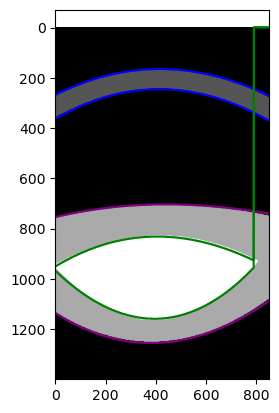

In [143]:
# curves = curves[:, 100:700]  # crop for better visualization
print('Cropped curves shape:', curves.shape)
plt.imshow(label[:, :], cmap='gray')
plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
plt.show()

,Layer,Value (mm)
0,GD Cornea Anterior,0.000000
1,GD Cornea Posterior,0.582057
2,GD Lense Anterior,3.234462
3,GD Nucleus Anterior,1.034571
4,GD Nucleus Posterior,1.589150
5,GD Lens Posterior,0.837969
6,D1,3.816519
7,D2,3.461691
8,RoC Cornea Anterior,4.779315
9,RoC Cornea Posterior,4.396361


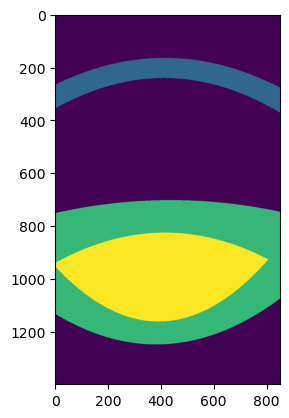

In [121]:
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/0-6/4/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/0-6/4/Vertical/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/6-0/4/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN069_JU_28_M/OS/6-0/4/Vertical/"

# data_root = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\0-6\4\Horizontal/"
# data_root = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\0-6\2\Vertical/"
# data_root = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\6-0\2\Horizontal/"
# data_root = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\6-0\2\Vertical/"_r

data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data/CN029_FK_24_M/OS/6-0D/0/Horizontal/"
data_root = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Raw Data/CN067_SC_26_F/OD/6-0/6/Vertical/"

bin_seg = bin_segmentation(mask=None)
label = bin_seg.get_mask(data_root=data_root)
# label = label[:, 215:635]
# plt.imshow(label)

analyzer = OpticalAnalyzer2()
results, curves, O = analyzer.raytracing(label)


gd_layers =results['gd']
roc = results["radii"]
gd_mean = [np.nanmean(gd) for gd in results["gd"]]
d1 = np.sum(gd_mean[:3])
d2 = np.sum(gd_mean[3:])

data = {
    "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                + ["D1", "D2"]+
            ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
    # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
    "Value (mm)": [*gd_mean, d1, d2, *roc]
}
df = pd.DataFrame(data)
df

# Loop with Metrics Calculation

Label shape: (1400, 850)
Original image shape: (512, 512)
Image tensor shape: torch.Size([1, 3, 512, 512])
Pred shape (C,H,W): (512, 512)
Curves shape: (6, 850)
Curves clean shape: (6, 850)
6
Curves shape: (6, 850)
Curves clean shape: (6, 850)
6


,Layer,Prediction (mm),Reference (mm),MAE,MPE (%)
0,GD Cornea Anterior,0.000000,0.000000,0.000000,NaN
1,GD Cornea Posterior,0.618309,0.582172,0.036137,6.207359
2,GD Lense Anterior,3.198766,3.234898,0.036132,1.116959
3,GD Nucleus Anterior,1.074487,1.035636,0.038851,3.751405
4,GD Nucleus Posterior,1.587140,1.583389,0.003751,0.236916
5,GD Lens Posterior,0.863006,0.840001,0.023005,2.738723
6,D1,3.817075,3.817070,0.000005,0.000131
7,D2,3.524633,3.459026,0.065607,1.896705
8,RoC Cornea Anterior,4.864064,4.770862,0.093202,1.953564
9,RoC Cornea Posterior,4.450881,4.392185,0.058696,1.336380


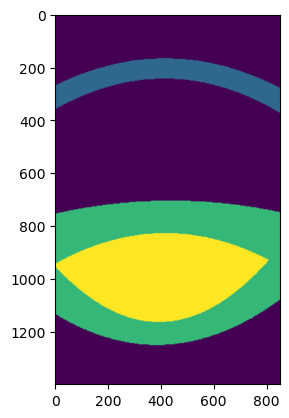

In [ ]:

# checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth" # Mix data
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251105_165715/checkpoints/DeepLabV3_ResNet50_best.pth"  # Mix2 data
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251106_091849/checkpoints/DeepLabV3_ResNet50_best.pth" # Mix2 data without augmentation+ combined loss
# checkpoint_path = "runs/ResNet50UNet_DAC_20251106_114438/checkpoints/ResNet50UNet_DAC_best.pth" # without padding, orginal size 1400x850 not working well
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251107_113953/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" #best so far
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251110_121848/checkpoints/DeepLabV3_ResNet50_best.pth"

checkpoint_path = "runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" # 512x512 padding (old data)
# checkpoint_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_310/DeepLabV3_ResNet50_epoch_10.pth"

img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"
label_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/labels/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"

# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/dataset/eye_data/images/val/CN035_JP_19_M_OD_6-0D_4_Horizontal.png"
# img_path ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/Image.png"

# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/0-6/0/Vertical/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/6-0/0/Horizontal/"
# data_root ="/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/New folder/New folder/CN068_IB_29_F/OS/6-0/0/Vertical/"

# checkpoint_path = "test/DeepLabV3_ResNet50_best_cb.pth" #nn.CrossEntropyLoss
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\0-6\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\0-6\4\Vertical\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\6-0\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN069_JU_28_M\OS\6-0\4\Vertical\Image.png"

# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\0-6\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\0-6\4\Vertical\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\6-0\4\Horizontal\Image.png"
# img_path = r"D:\PG_Gdansk\Torun_secondment\Experiments\dataset_eye\New folder\New folder\CN070_YC_27_M\OD\6-0\4\Vertical\Image.png"

# img_path = data_root + "Image.png"

label = Image.open(label_path).convert("L")  
label = undo_padding(np.array(label), original_size=(1400, 850), target_size=(512, 512))
plt.imshow(label)
print('Label shape:', np.array(label).shape)
predictor = SegPredictor2(checkpoint_path, num_classes=4, crop_size=512, resize=False, undo_padding=True)
image, pred = predictor.predict(img_path)

# pred = postprocess(pred, open_radius=12, close_radius=30)
# pred = clean(pred, min_size=30000, min_hole_size=100)
# pred = postprocess(pred, open_radius=10, close_radius=20)  # clean small noise
# pred = postprocess(pred, open_radius=20, close_radius=40)  # final smoothing

# Two-pass for perfect results
# pred = postprocess2(pred, close_radius=20, open_radius=10)  # light clean
# pred = postprocess2(pred, close_radius=40, open_radius=15)  # heavy smoothing

# image2 = image[:, 150:700]
# pred = pred[:, 150:700]
# label = label[:, 150:700]

# label = label[:, 215:635]
# pred = pred[:, 215:635]
# pred = smooth_maps(pred, ksize=1, sigma=4.0)
# pred = np.argmax(pred, axis=0).astype(np.uint8)  # Convert probabilities to class labels

# plt.imshow(pred[:, 215:635])

analyzer = OpticalAnalyzer2()
# results, curves, O = analyzer.raytracing(label)
results, curves, O = analyzer.raytracing(pred)
results_ref, curves_ref, O_ref = analyzer.raytracing(label)

gd_layers =results['gd']
roc = results["radii"]
gd_mean = [np.nanmean(gd) for gd in results["gd"]]
d1 = np.sum(gd_mean[:3])
d2 = np.sum(gd_mean[3:])

data = {
    "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                + ["D1", "D2"]+
            ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
    # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
    "Value (mm)": [*gd_mean, d1, d2, *roc]
}
df = pd.DataFrame(data)

# --- reference (label) ---
gd_mean_ref = [np.nanmean(gd) for gd in results_ref["gd"]]
d1_ref = np.sum(gd_mean_ref[:3])
d2_ref = np.sum(gd_mean_ref[3:])
roc_ref = results_ref["radii"]

df_ref = pd.DataFrame({
    "Layer": df["Layer"],  # same layer names
    "Value (mm)": [*gd_mean_ref, d1_ref, d2_ref, *roc_ref]
})

df_side = pd.DataFrame({
    "Layer": df["Layer"],
    "Prediction (mm)": df["Value (mm)"],
    "Reference (mm)": df_ref["Value (mm)"]
})

df_side["MAE"] = (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()

df_side["MPE (%)"] = (
    (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()
    / df_side["Reference (mm)"].replace(0, np.nan)  # avoid division by zero
) * 100


df_side
# csv_path = "optical_results.csv"
# excel_path = "optical_results.xlsx"
# df.to_csv(csv_path, index=False)
# df.to_excel(excel_path, index=False, engine="openpyxl")

# for idx, val in enumerate(gd_mean, start=1):
#     print(f"GD{idx}: {val:.4f} mm")
# print(f"d1: {d1:.3f} mm\nd2: {d2:.3f} mm")

# for idx, r in enumerate(results["radii"], start=1):
#     print(f"RoC {idx}: {r:.3f} mm")


### Loop over a group input image size 512x512 with padding

In [22]:
checkpoint_path = "runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" # 512x512 padding (old data)
# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"
# label_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/labels/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"

predictor = SegPredictor2(checkpoint_path, num_classes=4, crop_size=512, resize=False, undo_padding=True)



# image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/val"
# results_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/results_512_512_val/"

image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/set1 dataset/old_datasetall/images"
results_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/set1 dataset/"

os.makedirs(results_dir, exist_ok=True)
# csv_path = os.path.join(results_dir, "optical_results.csv")
# excel_path = os.path.join(results_dir, "optical_results.xlsx")
# curves_dir = os.path.join(results_dir, "curves.csv")


image_files = sorted(glob(os.path.join(image_dir, "*.png")))
label_files = sorted(glob(os.path.join(image_dir.replace("images", "labels"), "*.png")))

all_results = []
i = 0
for img_path, label_path in zip(image_files, label_files):

    image_name = os.path.basename(img_path)
    image_name = os.path.splitext(image_name)[0]
    label_name = os.path.basename(label_path)
    label_name = os.path.splitext(label_name)[0]
   
    assert image_name == label_name, "Image and label names do not match!"
    
    image, pred = predictor.predict(img_path)
    label = Image.open(label_path).convert("L")  
    label = undo_padding(np.array(label), original_size=(1400, 850), target_size=(512, 512))

    # pred = clean(pred, min_size=30000, min_hole_size=100)   # to remove small patches
    # pred = postprocess2(pred, close_radius=20, open_radius=10)  # light clean
    # pred = postprocess2(pred, close_radius=40, open_radius=15)  # heavy smoothing
    
    # image2 = image[:, 150:700]
    # pred = pred[:, 150:700]
    # label = label[:, 150:700]
    # pred = pred[:, 215:635]
    # label = label[:, 215:635]

    analyzer = OpticalAnalyzer2()
    results, curves, O = analyzer.raytracing(pred)
    results_ref, curves_ref, O_ref = analyzer.raytracing(label)

    gd_layers =results['gd']
    roc = results["radii"]
    gd_mean = [np.nanmean(gd) for gd in results["gd"]]
    d1 = np.sum(gd_mean[:3])
    d2 = np.sum(gd_mean[3:])

    data = {
        "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                    + ["D1", "D2"]+
                ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
        # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
        "Value (mm)": [*gd_mean, d1, d2, *roc]
    }
    df = pd.DataFrame(data)

    # --- reference (label) ---
    gd_mean_ref = [np.nanmean(gd) for gd in results_ref["gd"]]
    d1_ref = np.sum(gd_mean_ref[:3])
    d2_ref = np.sum(gd_mean_ref[3:])
    roc_ref = results_ref["radii"]

    df_ref = pd.DataFrame({
        "Layer": df["Layer"],  # same layer names
        "Value (mm)": [*gd_mean_ref, d1_ref, d2_ref, *roc_ref]
    })

    df_side = pd.DataFrame({
        "Layer": df["Layer"],
        "Prediction (mm)": df["Value (mm)"],
        "Reference (mm)": df_ref["Value (mm)"]
    })

    df_side["MAE"] = (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()

    df_side["MPE (%)"] = (
        (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()
        / df_side["Reference (mm)"].replace(0, np.nan)  # avoid division by zero
    ) * 100

    temp = df_side.copy()
    # temp["Image"] = image_name
    temp.insert(0, "Image", image_name) 
    all_results.append(temp)
    # df_side

    
    # df
    # final_dir = os.path.join(results_dir, image_name)
    final_dir = os.path.join(results_dir, "data")
    os.makedirs(final_dir, exist_ok=True)
    
    excel_path = os.path.join(final_dir, f"{image_name}_optical_results.xlsx")
    curves_dir = os.path.join(final_dir, f"{image_name}_curves.csv")
    curves_ref_dir = os.path.join(final_dir, f"{image_name}_curves_ref.csv")

    # df_side.to_csv(csv_path, index=False)
    df_side.to_excel(excel_path, index=False, engine="openpyxl")
    np.savetxt(curves_dir, curves, fmt="%.3f", delimiter=",")
    np.savetxt(curves_ref_dir, curves_ref, fmt="%.3f", delimiter=",")
    # print(df_side.round(4))

    plt.figure(figsize=(10, 6))
    plt.subplot(1,2,1)
    plt.imshow(pred[:, :], cmap='gray')

    plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
    plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
    plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
    plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
    plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
    plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
    plt.title(f"RoC Curves Predicted")

    plt.subplot(1,2,2)
    plt.imshow(label[:, :], cmap='gray')
    curves = curves_ref
    plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
    plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
    plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
    plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
    plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
    plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
    plt.title(f"RoC Curves Reference")
    # plt.savefig(os.path.join(final_dir, "curves.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(final_dir, f'{image_name}.png'), dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()

    # if i >=2:
    #     break
    # i += 1

print(f" {len(image_files)} images processed. Results saved in {results_dir}")
df_all = pd.concat(all_results, ignore_index=True)

layer_stats = (
    df_all.groupby("Layer")[["MAE", "MPE (%)"]]
    .agg(["mean", "std"])
)

layer_stats.columns = ["MAE_mean", "MAE_std", "MPE_mean", "MPE_std"]
layer_stats = layer_stats.reset_index()
df_all = df_all.merge(layer_stats, on="Layer", how="left")


print("Overall Layer-wise Statistics:")
print(layer_stats.round(4))

excel_path_all = os.path.join(results_dir, "optical_results_all.xlsx")
df_all.to_excel(excel_path_all, index=False, engine="openpyxl")

# Flatten MultiIndex columns (if present) so Excel writing works reliably,
# and write the DataFrame including its index.
if isinstance(layer_stats.columns, pd.MultiIndex):
    layer_stats.columns = [' '.join([str(c) for c in col]).strip() for col in layer_stats.columns.values]

layer_stats.to_excel(os.path.join(results_dir, "layer_mean_errors.xlsx"), index=True, engine="openpyxl")

 408 images processed. Results saved in /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/set1 dataset/
Overall Layer-wise Statistics:
                    Layer  MAE_mean  MAE_std  MPE_mean  MPE_std
0                      D1    0.0095   0.0071    0.2754   0.2084
1                      D2    0.0601   0.0529    1.7344   1.6188
2      GD Cornea Anterior    0.0000   0.0000       NaN      NaN
3     GD Cornea Posterior    0.0455   0.0185    8.0535   3.6138
4       GD Lens Posterior    0.0323   0.0594    4.0585   8.0697
5       GD Lense Anterior    0.0461   0.0154    1.5941   0.5344
6     GD Nucleus Anterior    0.0242   0.0193    2.3373   1.9626
7    GD Nucleus Posterior    0.0394   0.0329    2.5209   2.2411
8     RoC Cornea Anterior    0.7372   2.1501    5.1340   8.3743
9    RoC Cornea Posterior    0.5953   1.4569    4.9430   5.8263
10     RoC Lens Posterior    1.0905   2.2221    6.0424   7.5157
11     RoC Lense Anterior    1

In [225]:
def plot_curves(img, curves, title):
    plt.imshow(img, cmap="gray")
    colors = ["b","b","purple","g","g","purple"]
    for i in range(6):
        plt.plot(curves[i], color=colors[i])
    plt.title(title)

# plt.subplot(1,2,1)
# plot_curves(pred, curves, "RoC Predicted")

# plt.subplot(1,2,2)
# plot_curves(label, curves_ref, "RoC Reference")


 123 images processed. Results saved in /media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/results_850_1400_val_oldcheck/
Overall Layer-wise Statistics:
                    Layer  MAE_mean  MAE_std  MPE_mean  MPE_std
0                      D1    0.0102   0.0092    0.2909   0.2513
1                      D2    0.0220   0.0213    0.6343   0.6346
2      GD Cornea Anterior    0.0000   0.0000       NaN      NaN
3     GD Cornea Posterior    0.0123   0.0100    2.1499   1.7652
4       GD Lens Posterior    0.0494   0.0326    6.0123   4.2699
5       GD Lense Anterior    0.0109   0.0089    0.3734   0.2913
6     GD Nucleus Anterior    0.0442   0.0308    4.2109   2.9695
7    GD Nucleus Posterior    0.0609   0.0496    3.6745   2.8516
8     RoC Cornea Anterior    0.6492   1.5364    5.7003   4.9839
9    RoC Cornea Posterior    0.5912   1.0649    5.5369   4.3990
10     RoC Lens Posterior    0.9711   2.2572    5.8349   8.3004
11     RoC Lense Anterior    0.7348   1.0570    4

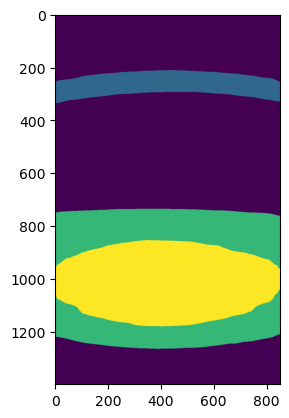

In [227]:
checkpoint_path = "runs/DeepLabV3_ResNet50_20251107_113953/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" #best so far
# checkpoint_path = "runs/DeepLabV3_ResNet50_20251028_Mix_data/checkpoints/DeepLabV3_ResNet50_best.pth"

# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"
# label_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/labels/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"

# predictor = SegPredictor2(checkpoint_path, num_classes=4, crop_size=512, resize=False, undo_padding=True, GN=True)
predictor = SegPredictor(checkpoint_path, num_classes=4, crop_size=512, resize=True)
analyzer = OpticalAnalyzer2()

# image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/new data/dataset/training/images/val" # new data 850x1400
image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data/images/val" # old data 850x1400

# image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train"

results_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/results_850_1400_val_oldcheck/"
os.makedirs(results_dir, exist_ok=True)
# csv_path = os.path.join(results_dir, "optical_results.csv")
# excel_path = os.path.join(results_dir, "optical_results.xlsx")
# curves_dir = os.path.join(results_dir, "curves.csv")


image_files = sorted(glob(os.path.join(image_dir, "*.png")))
label_files = sorted(glob(os.path.join(image_dir.replace("images", "labels"), "*.png")))

all_results = []
i = 0
for img_path, label_path in zip(image_files, label_files):

    image_name = os.path.basename(img_path)
    image_name = os.path.splitext(image_name)[0]
    label_name = os.path.basename(label_path)
    label_name = os.path.splitext(label_name)[0]
   
    assert image_name == label_name, "Image and label names do not match!"
    
    image, pred = predictor.predict(img_path)
    label = Image.open(label_path).convert("L")  
    label = np.array(label) #  no padding for 850x1400 images, convert to numpy array
    # label = undo_padding(np.array(label), original_size=(1400, 850), target_size=(512, 512))
    
    # image2 = image[:, 150:700]
    # pred = pred[:, 150:700]
    # label = label[:, 150:700]
    # pred = pred[:, 215:635]
    # label = label[:, 215:635]

    pred = clean(pred, min_size=30000, min_hole_size=100)   # to remove small patches
    # pred = postprocess2(pred, close_radius=20, open_radius=10)  # light clean
    # pred = postprocess2(pred, close_radius=40, open_radius=15)  # heavy smoothing

    # print('type of label:', type(label) , ' shape:', np.array(label).shape)
    # print('label unique values:', np.unique(np.array(label)))
    # print('label value:',label)
    plt.imshow(pred)
    # if True:
    #     continue
    # analyzer = OpticalAnalyzer2()
    results, curves, O = analyzer.raytracing(pred)
    results_ref, curves_ref, O_ref = analyzer.raytracing(label)

    gd_layers =results['gd']
    roc = results["radii"]
    gd_mean = [np.nanmean(gd) for gd in results["gd"]]
    d1 = np.sum(gd_mean[:3])
    d2 = np.sum(gd_mean[3:])

    data = {
        "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                    + ["D1", "D2"]+
                ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
        # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
        "Value (mm)": [*gd_mean, d1, d2, *roc]
    }
    df = pd.DataFrame(data)

    # --- reference (label) ---
    gd_mean_ref = [np.nanmean(gd) for gd in results_ref["gd"]]
    d1_ref = np.sum(gd_mean_ref[:3])
    d2_ref = np.sum(gd_mean_ref[3:])
    roc_ref = results_ref["radii"]

    df_ref = pd.DataFrame({
        "Layer": df["Layer"],  # same layer names
        "Value (mm)": [*gd_mean_ref, d1_ref, d2_ref, *roc_ref]
    })

    df_side = pd.DataFrame({
        "Layer": df["Layer"],
        "Prediction (mm)": df["Value (mm)"],
        "Reference (mm)": df_ref["Value (mm)"]
    })

    df_side["MAE"] = (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()

    df_side["MPE (%)"] = (
        (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()
        / df_side["Reference (mm)"].replace(0, np.nan)  # avoid division by zero
    ) * 100

    temp = df_side.copy()
    # temp["Image"] = image_name
    temp.insert(0, "Image", image_name) 
    all_results.append(temp)
    # df_side

    
    # df
    # final_dir = os.path.join(results_dir, image_name)
    final_dir = os.path.join(results_dir, "data")
    os.makedirs(final_dir, exist_ok=True)
    
    excel_path = os.path.join(final_dir, f"{image_name}_optical_results.xlsx")
    curves_dir = os.path.join(final_dir, f"{image_name}_curves.csv")
    curves_ref_dir = os.path.join(final_dir, f"{image_name}_curves_ref.csv")

    # df_side.to_csv(csv_path, index=False)
    df_side.to_excel(excel_path, index=False, engine="openpyxl")
    np.savetxt(curves_dir, curves, fmt="%.3f", delimiter=",")
    np.savetxt(curves_ref_dir, curves_ref, fmt="%.3f", delimiter=",")
    # print(df_side.round(4))

    plt.figure(figsize=(10, 6))
    plt.subplot(1,2,1)
    plot_curves(pred, curves, "RoC Predicted")

    plt.subplot(1,2,2)
    plot_curves(label, curves_ref, "RoC Reference")

    # plt.subplot(1,2,1)
    # plt.imshow(pred[:, :], cmap='gray')

    # plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
    # plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
    # plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
    # plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
    # plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
    # plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
    # plt.title(f"RoC Curves Predicted")

    # plt.subplot(1,2,2)
    # plt.imshow(label[:, :], cmap='gray')
    # curves = curves_ref
    # plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
    # plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
    # plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
    # plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
    # plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
    # plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
    # plt.title(f"RoC Curves Reference")
    # plt.savefig(os.path.join(final_dir, "curves.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(final_dir, f'{image_name}.png'), dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()

    # if i >=2:
    #     break
    # i += 1

print(f" {len(image_files)} images processed. Results saved in {results_dir}")
df_all = pd.concat(all_results, ignore_index=True)

layer_stats = (
    df_all.groupby("Layer")[["MAE", "MPE (%)"]]
    .agg(["mean", "std"])
)

layer_stats.columns = ["MAE_mean", "MAE_std", "MPE_mean", "MPE_std"]
layer_stats = layer_stats.reset_index()
df_all = df_all.merge(layer_stats, on="Layer", how="left")


print("Overall Layer-wise Statistics:")
print(layer_stats.round(4))

excel_path_all = os.path.join(results_dir, "optical_results_all.xlsx")
df_all.to_excel(excel_path_all, index=False, engine="openpyxl")

# Flatten MultiIndex columns (if present) so Excel writing works reliably,
# and write the DataFrame including its index.
if isinstance(layer_stats.columns, pd.MultiIndex):
    layer_stats.columns = [' '.join([str(c) for c in col]).strip() for col in layer_stats.columns.values]

layer_stats.to_excel(os.path.join(results_dir, "layer_mean_errors.xlsx"), index=True, engine="openpyxl")

## only processing images
without labels

In [21]:
checkpoint_path = "runs/DeepLabV3_ResNet50_20251006_140615/checkpoints/DeepLabV3_ResNet50_epoch_20.pth" # 512x512 padding (old data)
# img_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"
# label_path = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/labels/train/pCN067_SC_26_F_OD_6-0_6_Vertical.png"

predictor = SegPredictor2(checkpoint_path, num_classes=4, crop_size=512, resize=False, undo_padding=True)



# image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/Training_data_512_512/images/val"
# results_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/results_512_512_val/"

image_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/dataset/images"
results_dir = "/media/be-light/Data/PG_Gdansk/Torun_secondment/Experiments/dataset_eye/old data/full data for final test 08-12-2025/results3post_08-12-25/"

os.makedirs(results_dir, exist_ok=True)
# csv_path = os.path.join(results_dir, "optical_results.csv")
# excel_path = os.path.join(results_dir, "optical_results.xlsx")
# curves_dir = os.path.join(results_dir, "curves.csv")


image_files = sorted(glob(os.path.join(image_dir, "*.png")))
# label_files = sorted(glob(os.path.join(image_dir.replace("images", "labels"), "*.png")))

all_results = []
i = 0
for img_path in image_files:

    image_name = os.path.basename(img_path)
    image_name = os.path.splitext(image_name)[0]
    # label_name = os.path.basename(label_path)
    # label_name = os.path.splitext(label_name)[0]
    # print('Processing image:', image_name)
    # assert image_name == label_name, "Image and label names do not match!"
    
    image, pred = predictor.predict(img_path)
    # label = Image.open(label_path).convert("L")  
    # label = undo_padding(np.array(label), original_size=(1400, 850), target_size=(512, 512))

    pred = clean(pred, min_size=30000, min_hole_size=100)   # to remove small patches
    pred = postprocess2(pred, close_radius=20, open_radius=10)  # light clean
    # pred = postprocess2(pred, close_radius=40, open_radius=15)  # heavy smoothing
    
    # image2 = image[:, 150:700]
    # pred = pred[:, 150:700]
    # label = label[:, 150:700]
    # pred = pred[:, 215:635]
    # label = label[:, 215:635]

    analyzer = OpticalAnalyzer2()
    results, curves, O = analyzer.raytracing(pred)
    # results_ref, curves_ref, O_ref = analyzer.raytracing(label)

    gd_layers =results['gd']
    roc = results["radii"]
    gd_mean = [np.nanmean(gd) for gd in results["gd"]]
    d1 = np.sum(gd_mean[:3])
    d2 = np.sum(gd_mean[3:])

    data = {
        "Layer": ["GD Cornea Anterior", "GD Cornea Posterior", "GD Lense Anterior", "GD Nucleus Anterior","GD Nucleus Posterior", "GD Lens Posterior"]
                    + ["D1", "D2"]+
                ["RoC Cornea Anterior", "RoC Cornea Posterior", "RoC Lense Anterior", "RoC Nucleus Anterior","RoC Nucleus Posterior", "RoC Lens Posterior"],
        # "Layer": [f"GD{i+1}" for i in range(len(gd_mean))] + ["d1", "d2"] + [f"RoC{i+1}" for i in range(len(roc))],
        "Value (mm)": [*gd_mean, d1, d2, *roc]
    }
    df = pd.DataFrame(data)

    # --- reference (label) ---
    # gd_mean_ref = [np.nanmean(gd) for gd in results_ref["gd"]]
    # d1_ref = np.sum(gd_mean_ref[:3])
    # d2_ref = np.sum(gd_mean_ref[3:])
    # roc_ref = results_ref["radii"]

    # df_ref = pd.DataFrame({
    #     "Layer": df["Layer"],  # same layer names
    #     "Value (mm)": [*gd_mean_ref, d1_ref, d2_ref, *roc_ref]
    # })

    df_side = pd.DataFrame({
        "Layer": df["Layer"],
        "Prediction (mm)": df["Value (mm)"],
        # "Reference (mm)": df_ref["Value (mm)"]
    })

    # df_side["MAE"] = (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()

    # df_side["MPE (%)"] = (
    #     (df_side["Prediction (mm)"] - df_side["Reference (mm)"]).abs()
    #     / df_side["Reference (mm)"].replace(0, np.nan)  # avoid division by zero
    # ) * 100

    temp = df_side.copy()
    # temp["Image"] = image_name
    temp.insert(0, "Image", image_name) 
    all_results.append(temp)
    # df_side

    
    # df
    # final_dir = os.path.join(results_dir, image_name)
    final_dir = os.path.join(results_dir, "data")
    os.makedirs(final_dir, exist_ok=True)
    
    excel_path = os.path.join(final_dir, f"{image_name}_optical_results.xlsx")
    curves_dir = os.path.join(final_dir, f"{image_name}_curves.csv")
    curves_ref_dir = os.path.join(final_dir, f"{image_name}_curves_ref.csv")

    # df_side.to_csv(csv_path, index=False)
    df_side.to_excel(excel_path, index=False, engine="openpyxl")
    np.savetxt(curves_dir, curves, fmt="%.3f", delimiter=",")
    # np.savetxt(curves_ref_dir, curves_ref, fmt="%.3f", delimiter=",")
    # print(df_side.round(4))

    plt.figure(figsize=(10, 6))
    # plt.subplot(1,2,1)
    plt.imshow(pred[:, :], cmap='gray')

    # plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
    # plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
    # plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
    # plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
    # plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
    # plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
    plt.title(f"RoC Curves Predicted")

    # plt.subplot(1,2,2)
    # plt.imshow(label[:, :], cmap='gray')
    # curves = curves_ref
    # plt.plot(range(curves.shape[1]), curves[0], color='b')  # Cornea anterior
    # plt.plot(range(curves.shape[1]), curves[1], color='b')  # Cornea posterior
    # plt.plot(range(curves.shape[1]), curves[2], color='purple')  # Lens anterior
    # plt.plot(range(curves.shape[1]), curves[3], color='g')  # Nucleus anterior
    # plt.plot(range(curves[4].shape[0]), curves[4], color='g')  # Nucleus posterior
    # plt.plot(range(curves[5].shape[0]), curves[5], color='purple')  # Lens posterior
    # plt.title(f"RoC Curves Reference")
    # plt.savefig(os.path.join(final_dir, "curves.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(final_dir, f'{image_name}.png'), dpi=300, bbox_inches='tight')
    # plt.show()
    plt.close()

    # if i >=2:
    #     break
    # i += 1

print(f" {len(image_files)} images processed. Results saved in {results_dir}")
df_all = pd.concat(all_results, ignore_index=True)

# layer_stats = (
#     df_all.groupby("Layer")[["MAE", "MPE (%)"]]
#     .agg(["mean", "std"])
# )

# layer_stats.columns = ["MAE_mean", "MAE_std", "MPE_mean", "MPE_std"]
# layer_stats = layer_stats.reset_index()
# df_all = df_all.merge(layer_stats, on="Layer", how="left")


# print("Overall Layer-wise Statistics:")
# print(layer_stats.round(4))

excel_path_all = os.path.join(results_dir, "optical_results_all.xlsx")
df_all.to_excel(excel_path_all, index=False, engine="openpyxl")

# Flatten MultiIndex columns (if present) so Excel writing works reliably,
# and write the DataFrame including its index.
# if isinstance(layer_stats.columns, pd.MultiIndex):
#     layer_stats.columns = [' '.join([str(c) for c in col]).strip() for col in layer_stats.columns.values]

# layer_stats.to_excel(os.path.join(results_dir, "layer_mean_errors.xlsx"), index=True, engine="openpyxl")

KeyboardInterrupt: 